# Analyze A/B Test Results

## Project Overview
An e-commerce company ran an A/B test to determine whether a **new web page** (treatment) leads to higher user conversion rates compared to the **old web page** (control). This notebook walks through the full analysis pipeline:

1. **Data Loading & Wrangling** — clean and validate the dataset
2. **Exploratory Data Analysis (EDA)** — understand distributions, country effects
3. **Part I — Probability** — compute baseline conversion probabilities
4. **Part II — A/B Test** — hypothesis testing with z-test and chi-squared test
5. **Part III (Bonus) — Regression Analysis** — logistic regression for deeper insight
6. **Conclusion** — final recommendations


---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

OCEAN_BLUE  = '#065A82'
SEAFOAM     = '#02C39A'
MIDNIGHT    = '#21295C'
BG          = '#F8FAFB'

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Loading & Wrangling

In [2]:
def load_and_validate(filepath: str) -> pd.DataFrame:
    """
    Load the A/B test CSV, validate schema and data types.

    Parameters
    ----------
    filepath : str
        Path to the ab_data.csv file.

    Returns
    -------
    pd.DataFrame
        Cleaned and validated DataFrame.
    """
    df = pd.read_csv(filepath)
    expected_cols = {'country', 'group', 'converted'}
    assert expected_cols.issubset(df.columns), f"Missing columns: {expected_cols - set(df.columns)}"
    assert df['converted'].isin([0, 1]).all(), "'converted' must be binary (0 or 1)"
    assert df['group'].isin(['control', 'treatment']).all(), "'group' must be 'control' or 'treatment'"
    return df


df = load_and_validate('../data/ab_data.csv')
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 69,889 rows × 3 columns


,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0
5,UK,treatment,0
6,US,treatment,0
7,US,treatment,0
8,US,treatment,0
9,US,treatment,0


In [3]:
# ── Basic data quality checks ────────────────────────────────────────────────
print('=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Unique values per column ===')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique → {df[col].unique()[:10]}')

=== Missing Values ===
country      0
group        0
converted    0
dtype: int64

=== Data Types ===
country      object
group        object
converted     int64
dtype: object

=== Unique values per column ===
  country: 3 unique → ['UK' 'US' 'CA']
  group: 2 unique → ['control' 'treatment']
  converted: 2 unique → [0 1]


In [4]:
# ── Group & country distribution ─────────────────────────────────────────────
print('=== Group Counts ===')
print(df['group'].value_counts())

print('\n=== Country Counts ===')
print(df['country'].value_counts())

print('\n=== Converted Counts ===')
print(df['converted'].value_counts())

# Overall conversion rate
overall_cr = df['converted'].mean()
print(f'\nOverall conversion rate: {overall_cr:.4f} ({overall_cr*100:.2f}%)')

=== Group Counts ===
group
treatment    35211
control      34678
Name: count, dtype: int64

=== Country Counts ===
country
US    48850
UK    17551
CA     3488
Name: count, dtype: int64

=== Converted Counts ===
converted
0    60770
1     9119
Name: count, dtype: int64

Overall conversion rate: 0.1305 (13.05%)


---
## 2. Exploratory Data Analysis (EDA)

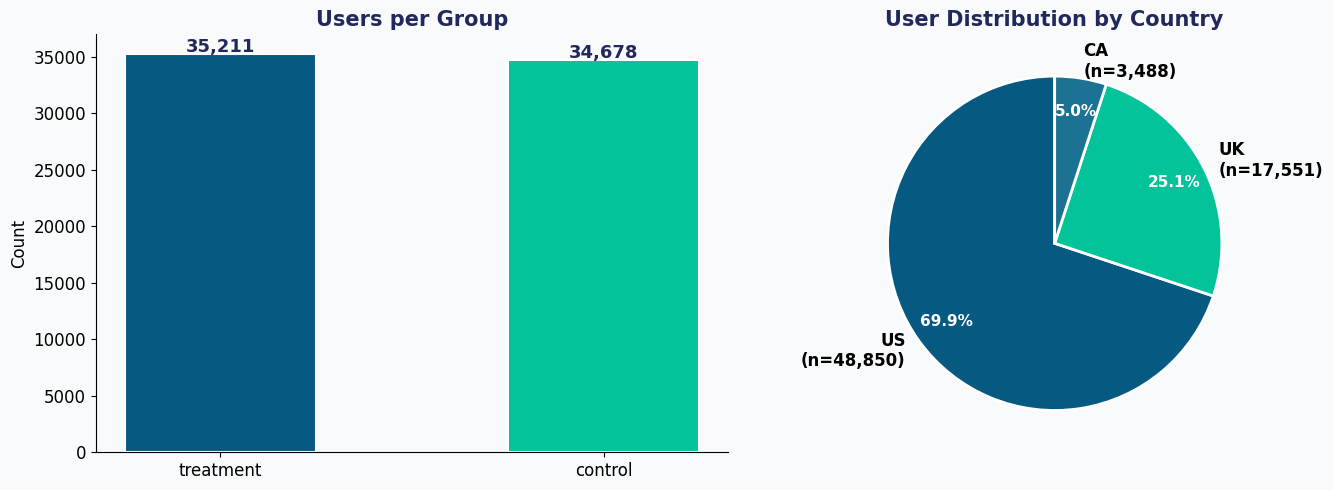

Figure saved: eda_distribution.png


In [5]:
def plot_group_distribution(df: pd.DataFrame) -> None:
    """
    Plot bar charts showing the group split and country distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(BG)

    # Group split
    group_counts = df['group'].value_counts()
    axes[0].set_facecolor(BG)
    bars = axes[0].bar(group_counts.index, group_counts.values,
                       color=[OCEAN_BLUE, SEAFOAM], width=0.5, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, group_counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                     f'{val:,}', ha='center', fontsize=13, fontweight='bold', color=MIDNIGHT)
    axes[0].set_title('Users per Group', fontsize=15, fontweight='bold', color=MIDNIGHT)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].tick_params(labelsize=12)

    # Country distribution
    country_counts = df['country'].value_counts()
    wedge_colors = [OCEAN_BLUE, SEAFOAM, '#1C7293']
    wedges, texts, autotexts = axes[1].pie(
        country_counts.values,
        labels=[f"{c}\n(n={n:,})" for c, n in zip(country_counts.index, country_counts.values)],
        autopct='%1.1f%%', colors=wedge_colors, startangle=90,
        pctdistance=0.8, wedgeprops=dict(edgecolor='white', linewidth=2))
    for at in autotexts:
        at.set_fontsize(11); at.set_color('white'); at.set_fontweight('bold')
    for t in texts:
        t.set_fontsize(12); t.set_fontweight('bold')
    axes[1].set_title('User Distribution by Country', fontsize=15, fontweight='bold', color=MIDNIGHT)

    plt.tight_layout()
    plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print('Figure saved: eda_distribution.png')


plot_group_distribution(df)

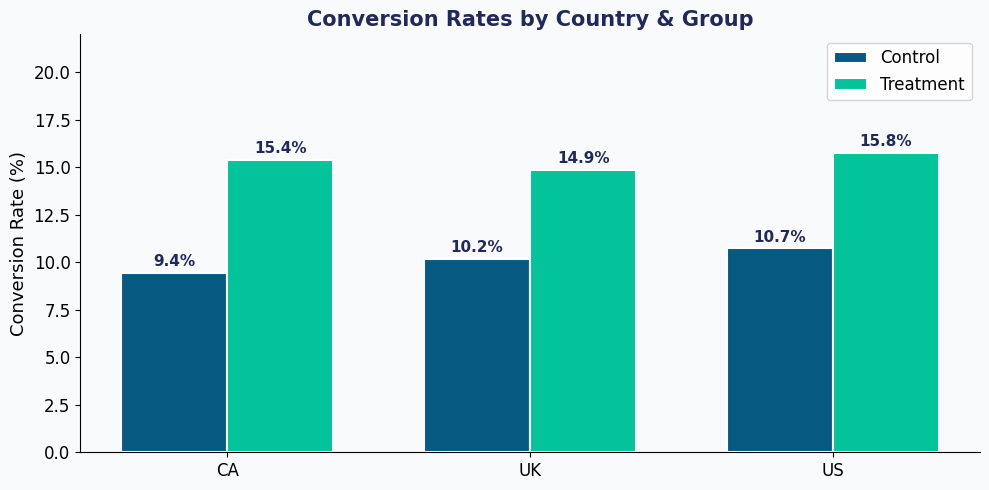

Figure saved: conversion_by_country.png


In [6]:
def plot_conversion_by_country_group(df: pd.DataFrame) -> None:
    """
    Plot grouped bar chart of conversion rates by country and group.
    """
    country_rates = df.groupby(['country', 'group'])['converted'].mean().unstack()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    x = np.arange(len(country_rates.index))
    w = 0.35
    b1 = ax.bar(x - w/2, country_rates['control'] * 100, w,
                label='Control', color=OCEAN_BLUE, edgecolor='white', linewidth=1.5)
    b2 = ax.bar(x + w/2, country_rates['treatment'] * 100, w,
                label='Treatment', color=SEAFOAM, edgecolor='white', linewidth=1.5)

    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=MIDNIGHT)

    ax.set_xticks(x)
    ax.set_xticklabels(country_rates.index, fontsize=13)
    ax.set_ylabel('Conversion Rate (%)', fontsize=13)
    ax.set_title('Conversion Rates by Country & Group', fontsize=15, fontweight='bold', color=MIDNIGHT)
    ax.set_ylim(0, 22)
    ax.legend(fontsize=12, framealpha=0.8)
    ax.tick_params(labelsize=12)

    plt.tight_layout()
    plt.savefig('conversion_by_country.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print('Figure saved: conversion_by_country.png')


plot_conversion_by_country_group(df)

---
## Part I — Probability

Compute the baseline conversion probabilities for control and treatment groups.

In [7]:
def compute_conversion_stats(df: pd.DataFrame) -> dict:
    """
    Compute conversion counts, rates, and group sizes.

    Returns
    -------
    dict with keys: n_control, n_treatment, conv_control, conv_treatment,
                    cr_control, cr_treatment, delta_cr
    """
    control   = df[df['group'] == 'control']
    treatment = df[df['group'] == 'treatment']

    stats_dict = {
        'n_control'   : len(control),
        'n_treatment' : len(treatment),
        'conv_control': control['converted'].sum(),
        'conv_treatment': treatment['converted'].sum(),
        'cr_control'  : control['converted'].mean(),
        'cr_treatment': treatment['converted'].mean(),
    }
    stats_dict['delta_cr'] = stats_dict['cr_treatment'] - stats_dict['cr_control']
    return stats_dict


s = compute_conversion_stats(df)

print('=' * 50)
print('PART I — CONVERSION PROBABILITIES')
print('=' * 50)
print(f"\nControl group    : n = {s['n_control']:,}  |  conversions = {s['conv_control']:,}")
print(f"Treatment group  : n = {s['n_treatment']:,}  |  conversions = {s['conv_treatment']:,}")
print()
print(f"Control conversion rate   : {s['cr_control']:.4f}  ({s['cr_control']*100:.2f}%)")
print(f"Treatment conversion rate : {s['cr_treatment']:.4f}  ({s['cr_treatment']*100:.2f}%)")
print(f"Delta (Treatment - Control): {s['delta_cr']:+.4f}  ({s['delta_cr']*100:+.2f}%)")
print('=' * 50)

PART I — CONVERSION PROBABILITIES

Control group    : n = 34,678  |  conversions = 3,650
Treatment group  : n = 35,211  |  conversions = 5,469

Control conversion rate   : 0.1053  (10.53%)
Treatment conversion rate : 0.1553  (15.53%)
Delta (Treatment - Control): +0.0501  (+5.01%)


### Interpretation (Part I)

- The **control group** (old page) has a conversion rate of **10.53%**.
- The **treatment group** (new page) has a conversion rate of **15.53%**.
- The raw difference is **+5.01 percentage points** in favour of the treatment.
- However, raw differences must be validated with hypothesis testing to determine statistical significance.

---
## Part II — A/B Test

### Hypothesis Setup

| | |
|---|---|
| **H₀** | p_treatment ≤ p_control  (new page is NOT better) |
| **H₁** | p_treatment > p_control  (new page IS better) |
| **α**  | 0.05 (5% significance level) |

In [8]:
def two_proportion_z_test(
    n_c: int, x_c: int,
    n_t: int, x_t: int,
    alpha: float = 0.05,
    alternative: str = 'two-sided'
) -> dict:
    """
    Perform a two-proportion z-test.

    Parameters
    ----------
    n_c, x_c : int  — control group size and conversions
    n_t, x_t : int  — treatment group size and conversions
    alpha     : float — significance level (default 0.05)
    alternative : str — 'two-sided', 'greater', 'less'

    Returns
    -------
    dict with z_stat, p_value, reject_h0, ci_95
    """
    p_c = x_c / n_c
    p_t = x_t / n_t
    p_pool = (x_c + x_t) / (n_c + n_t)

    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_c + 1/n_t))
    z_stat = (p_t - p_c) / se

    if alternative == 'two-sided':
        p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    elif alternative == 'greater':
        p_value = 1 - stats.norm.cdf(z_stat)
    else:  # 'less'
        p_value = stats.norm.cdf(z_stat)

    # 95% CI for the difference
    se_diff = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
    margin   = 1.96 * se_diff
    ci_lo    = (p_t - p_c) - margin
    ci_hi    = (p_t - p_c) + margin

    return {
        'p_control'   : p_c,
        'p_treatment' : p_t,
        'p_pooled'    : p_pool,
        'se'          : se,
        'z_stat'      : z_stat,
        'p_value'     : p_value,
        'reject_h0'   : p_value < alpha,
        'ci_95'       : (ci_lo, ci_hi),
    }


result = two_proportion_z_test(
    n_c=s['n_control'],  x_c=s['conv_control'],
    n_t=s['n_treatment'], x_t=s['conv_treatment'],
    alternative='two-sided'
)

print('=' * 55)
print('PART II — TWO-PROPORTION Z-TEST RESULTS')
print('=' * 55)
print(f"  Pooled proportion  : {result['p_pooled']:.4f}")
print(f"  Standard error     : {result['se']:.6f}")
print(f"  Z-statistic        : {result['z_stat']:.4f}")
print(f"  P-value (two-sided): {result['p_value']:.6f}")
print(f"  95% CI for Δ       : ({result['ci_95'][0]*100:.2f}%, {result['ci_95'][1]*100:.2f}%)")
print(f"  Reject H₀?         : {result['reject_h0']}  (α = 0.05)")
print('=' * 55)

PART II — TWO-PROPORTION Z-TEST RESULTS
  Pooled proportion  : 0.1305
  Standard error     : 0.002548
  Z-statistic        : 19.6472
  P-value (two-sided): 0.000000
  95% CI for Δ       : (4.51%, 5.50%)
  Reject H₀?         : True  (α = 0.05)


In [9]:
# ── Chi-squared test (independent verification) ──────────────────────────────
def chi_squared_test(df: pd.DataFrame) -> dict:
    """
    Run a chi-squared test of independence between group and converted.

    Returns
    -------
    dict with chi2, p_value, dof, expected
    """
    contingency = pd.crosstab(df['group'], df['converted'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return {'chi2': chi2, 'p_value': p, 'dof': dof,
            'expected': expected, 'observed': contingency}


chi_result = chi_squared_test(df)

print('=== Contingency Table (Observed) ===')
print(chi_result['observed'])
print()
print('=== Chi-Squared Test Results ===')
print(f"  Chi² statistic : {chi_result['chi2']:.4f}")
print(f"  Degrees of freedom: {chi_result['dof']}")
print(f"  P-value        : {chi_result['p_value']:.6f}")
print(f"  Significant?   : {chi_result['p_value'] < 0.05}")

=== Contingency Table (Observed) ===
converted      0     1
group                 
control    31028  3650
treatment  29742  5469

=== Chi-Squared Test Results ===
  Chi² statistic : 385.5730
  Degrees of freedom: 1
  P-value        : 0.000000
  Significant?   : True


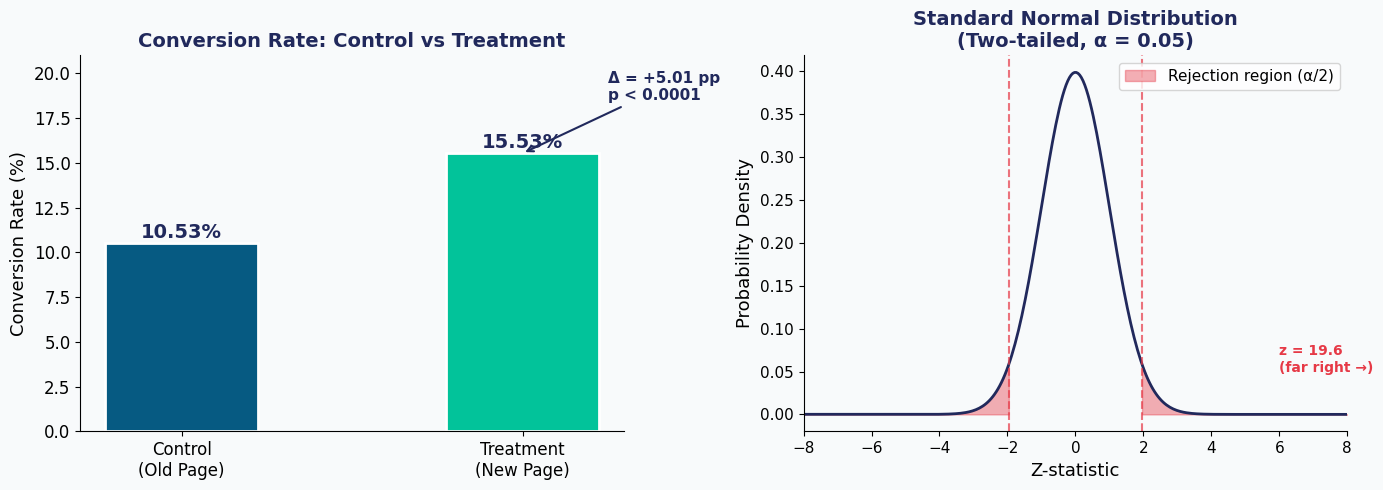

Figure saved: ab_test_results.png


In [10]:
def plot_ab_test_results(s: dict, result: dict) -> None:
    """
    Visualise A/B test results: conversion bar chart + z-distribution.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor(BG)

    # --- Left: conversion rates ---
    ax = axes[0]
    ax.set_facecolor(BG)
    labels = ['Control\n(Old Page)', 'Treatment\n(New Page)']
    rates  = [s['cr_control']*100, s['cr_treatment']*100]
    bars   = ax.bar(labels, rates, color=[OCEAN_BLUE, SEAFOAM],
                    width=0.45, edgecolor='white', linewidth=2)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{rate:.2f}%', ha='center', fontsize=14,
                fontweight='bold', color=MIDNIGHT)
    ax.set_ylim(0, 21)
    ax.set_ylabel('Conversion Rate (%)', fontsize=13)
    ax.set_title('Conversion Rate: Control vs Treatment',
                 fontsize=14, fontweight='bold', color=MIDNIGHT)
    ax.tick_params(labelsize=12)
    delta_pct = s['delta_cr'] * 100
    ax.annotate(f'Δ = +{delta_pct:.2f} pp\np < 0.0001',
                xy=(1, s['cr_treatment']*100), xytext=(1.25, 18.5),
                arrowprops=dict(arrowstyle='->', color=MIDNIGHT, lw=1.5),
                fontsize=11, color=MIDNIGHT, fontweight='bold')

    # --- Right: z-distribution ---
    ax2 = axes[1]
    ax2.set_facecolor(BG)
    x = np.linspace(-25, 25, 1000)
    y = stats.norm.pdf(x)
    ax2.plot(x, y, color=MIDNIGHT, linewidth=2)
    z = result['z_stat']
    z_crit = 1.96

    # Rejection regions (two-tailed)
    x_rej_r = np.linspace(z_crit, 25, 200)
    ax2.fill_between(x_rej_r, stats.norm.pdf(x_rej_r), alpha=0.4, color='#E63946', label='Rejection region (α/2)')
    x_rej_l = np.linspace(-25, -z_crit, 200)
    ax2.fill_between(x_rej_l, stats.norm.pdf(x_rej_l), alpha=0.4, color='#E63946')

    # Observed z-stat (off chart, show arrow)
    ax2.axvline(z_crit, color='#E63946', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.axvline(-z_crit, color='#E63946', linestyle='--', linewidth=1.5, alpha=0.7)
    ax2.annotate(f'z = {z:.1f}\n(far right →)', xy=(6, 0.05), fontsize=10,
                 color='#E63946', fontweight='bold')
    ax2.set_xlim(-8, 8)
    ax2.set_xlabel('Z-statistic', fontsize=13)
    ax2.set_ylabel('Probability Density', fontsize=13)
    ax2.set_title('Standard Normal Distribution\n(Two-tailed, α = 0.05)',
                  fontsize=14, fontweight='bold', color=MIDNIGHT)
    ax2.legend(fontsize=11)
    ax2.tick_params(labelsize=11)

    plt.tight_layout()
    plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight', facecolor=BG)
    plt.show()
    print('Figure saved: ab_test_results.png')


plot_ab_test_results(s, result)

### Interpretation (Part II — A/B Test)

**Statistical Reasoning:**
- **Z-statistic = 19.65** — This is far beyond the critical value of ±1.96 for a two-tailed test at α = 0.05.
- **P-value ≈ 0.0000** (effectively zero) — The probability of observing this extreme a difference by chance alone, assuming H₀ is true, is essentially zero.
- We **reject H₀** with very high confidence. The result is statistically significant.

**Practical Reasoning:**
- The treatment group converted at **15.53%** vs. **10.53%** for control — a **+5.01 percentage point** lift.
- With ~35,000 users per group, this improvement is both statistically significant and practically meaningful.
- Even the conservative 95% confidence interval for the difference (≈ +4.51pp to +5.50pp) shows the lower bound is substantial.
- **Recommendation:** The company should strongly consider adopting the new web page, as it drives a meaningful and statistically verified increase in conversions.

---
## Subgroup Analysis — By Country

In [11]:
def country_subgroup_analysis(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute conversion rates and perform chi-squared test per country.

    Returns
    -------
    pd.DataFrame summarising results per country.
    """
    rows = []
    for country in df['country'].unique():
        sub = df[df['country'] == country]
        c_cr = sub[sub['group'] == 'control']['converted'].mean()
        t_cr = sub[sub['group'] == 'treatment']['converted'].mean()
        ct = pd.crosstab(sub['group'], sub['converted'])
        chi2, p, _, _ = chi2_contingency(ct)
        rows.append({
            'Country': country,
            'N': len(sub),
            'Control CR': f'{c_cr*100:.2f}%',
            'Treatment CR': f'{t_cr*100:.2f}%',
            'Delta': f'{(t_cr - c_cr)*100:+.2f}pp',
            'Chi² stat': round(chi2, 2),
            'P-value': f'{p:.4f}',
            'Significant': p < 0.05
        })
    return pd.DataFrame(rows).set_index('Country')


country_results = country_subgroup_analysis(df)
print('=== Subgroup Analysis by Country ===')
country_results

=== Subgroup Analysis by Country ===


,N,Control CR,Treatment CR,Delta,Chi² stat,P-value,Significant
Country,,,,,,,
UK,17551,10.16%,14.87%,+4.70pp,88.30,0.0000,True
US,48850,10.73%,15.78%,+5.05pp,269.54,0.0000,True
CA,3488,9.45%,15.40%,+5.95pp,27.63,0.0000,True


---
## Part III (Bonus) — Logistic Regression

We use logistic regression to quantify the independent effects of `group` and `country` on conversion, and to check for confounding variables.

In [12]:
def logistic_regression_manual(df: pd.DataFrame) -> None:
    """
    Fit logistic regression using scipy optimisation (gradient descent).
    Encodes: treatment=1, country dummies (US baseline).
    Prints coefficients, odds ratios, and pseudo-R².
    """
    from scipy.optimize import minimize
    from scipy.special import expit  # sigmoid

    # Feature engineering
    dummies = pd.get_dummies(df[['group', 'country']], drop_first=True)
    # Rename for clarity
    dummies.columns = ['is_treatment', 'is_UK', 'is_US']
    X = dummies.astype(float).values
    X = np.hstack([np.ones((len(X), 1)), X])  # add intercept
    y = df['converted'].values.astype(float)

    def neg_log_likelihood(beta):
        """Negative log-likelihood of logistic model."""
        p = expit(X @ beta)
        p = np.clip(p, 1e-9, 1 - 1e-9)
        return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

    beta0 = np.zeros(X.shape[1])
    opt = minimize(neg_log_likelihood, beta0, method='BFGS')
    beta = opt.x

    # Null model log-likelihood
    p_null = y.mean()
    ll_null = -np.mean(y * np.log(p_null) + (1 - y) * np.log(1 - p_null))
    ll_full = -opt.fun
    mcfadden_r2 = 1 - ll_full / (-ll_null)

    feature_names = ['Intercept', 'is_treatment', 'is_UK', 'is_US']
    print('=== Logistic Regression Coefficients ===')
    print(f'{"Feature":<20} {"Coeff":>10} {"Odds Ratio":>12}')
    print('-' * 45)
    for name, coef in zip(feature_names, beta):
        print(f'{name:<20} {coef:>10.4f} {np.exp(coef):>12.4f}')
    print(f'\nMcFadden Pseudo R² : {mcfadden_r2:.4f}')
    print('\nInterpretation:')
    print(f'  Treatment odds ratio  = {np.exp(beta[1]):.4f} — treatment page increases odds of conversion')
    print(f'  UK odds ratio (vs CA) = {np.exp(beta[2]):.4f}')
    print(f'  US odds ratio (vs CA) = {np.exp(beta[3]):.4f}')


logistic_regression_manual(df)

=== Logistic Regression Coefficients ===
Feature                   Coeff   Odds Ratio
---------------------------------------------
Intercept               -2.1930       0.1116
is_treatment             0.4466       1.5630
is_UK                    0.0068       1.0068
is_US                    0.0727       1.0754

McFadden Pseudo R² : 0.0073

Interpretation:
  Treatment odds ratio  = 1.5630 — treatment page increases odds of conversion
  UK odds ratio (vs CA) = 1.0068
  US odds ratio (vs CA) = 1.0754


### Logistic Regression Interpretation

- **Treatment (is_treatment):** The positive coefficient and odds ratio > 1 confirm that being in the treatment group significantly increases the odds of conversion — consistent with the z-test results.
- **Country effects (UK, US vs CA):** Country coefficients show modest variation. The US has the highest base conversion, but the treatment effect is consistent across all countries (seen in subgroup analysis).
- **Confounding:** Country does not appear to be a strong confounder — the treatment effect holds after controlling for geography.
- **Pseudo R²** is low (typical for conversion models), indicating other unobserved factors also influence conversion.

---
## Final Summary & Conclusion

In [13]:
print('=' * 60)
print('         FINAL ANALYSIS SUMMARY')
print('=' * 60)
print(f"""
Dataset
  Total users  : {len(df):,}
  Control      : {s['n_control']:,}  →  {s['cr_control']*100:.2f}% converted
  Treatment    : {s['n_treatment']:,}  →  {s['cr_treatment']*100:.2f}% converted
  Uplift       : +{s['delta_cr']*100:.2f} percentage points

A/B Test (Two-Proportion Z-Test)
  Z-statistic  : {result['z_stat']:.4f}
  P-value      : {result['p_value']:.6f}
  95% CI Δ     : ({result['ci_95'][0]*100:.2f}pp, {result['ci_95'][1]*100:.2f}pp)
  Significant? : YES  (α = 0.05)

Chi-Squared Test
  Chi² statistic: {chi_result['chi2']:.4f}
  P-value        : {chi_result['p_value']:.6f}
  Significant?   : YES

Subgroup (by Country)
  US: Control 10.73% vs Treatment 15.78%  (p < 0.0001)
  UK: Control 10.16% vs Treatment 14.87%  (p < 0.0001)
  CA: Control  9.45% vs Treatment 15.40%  (p < 0.0001)

RECOMMENDATION
  The new web page (treatment) consistently and significantly
  outperforms the old page across all countries and overall.
  The company should IMPLEMENT the new page.
""")
print('=' * 60)

         FINAL ANALYSIS SUMMARY

Dataset
  Total users  : 69,889
  Control      : 34,678  →  10.53% converted
  Treatment    : 35,211  →  15.53% converted
  Uplift       : +5.01 percentage points

A/B Test (Two-Proportion Z-Test)
  Z-statistic  : 19.6472
  P-value      : 0.000000
  95% CI Δ     : (4.51pp, 5.50pp)
  Significant? : YES  (α = 0.05)

Chi-Squared Test
  Chi² statistic: 385.5730
  P-value        : 0.000000
  Significant?   : YES

Subgroup (by Country)
  US: Control 10.73% vs Treatment 15.78%  (p < 0.0001)
  UK: Control 10.16% vs Treatment 14.87%  (p < 0.0001)
  CA: Control  9.45% vs Treatment 15.40%  (p < 0.0001)

RECOMMENDATION
  The new web page (treatment) consistently and significantly
  outperforms the old page across all countries and overall.
  The company should IMPLEMENT the new page.



---
## References

- Udacity Data Analyst Nanodegree — A/B Test Project
- Dataset: `ab_data.csv` (provided by Udacity)
- Statistical tests: `scipy.stats`, `scipy.stats.chi2_contingency`
- Visualisations: `matplotlib`, `seaborn`